# Task 3.2 - Failure Mode Demonstration

## Scenario
We construct synthetic time series where early prefixes are intentionally ambiguous across classes, but later segments are class-separable.

## Why this should fail
This setup directly violates Assumption 1 from Task 1.2 (early prefixes must contain class-discriminative information).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

SEED = 42
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

SERIES_LEN = 120
PIVOT = 50  # first 50 points are made intentionally ambiguous
N_TRAIN = 400
N_TEST = 200


def make_series(cls):
    # Early prefix: shared pattern for both classes -> ambiguity for early prediction
    prefix_base = np.sin(np.linspace(0, 3 * np.pi, PIVOT))
    prefix = prefix_base + RNG.normal(0, 0.12, PIVOT)

    t = np.linspace(0, 2 * np.pi, SERIES_LEN - PIVOT)
    if cls == 0:
        tail = np.sin(t) + 1.0 + RNG.normal(0, 0.10, SERIES_LEN - PIVOT)
    else:
        tail = -np.sin(t) - 1.0 + RNG.normal(0, 0.10, SERIES_LEN - PIVOT)

    return np.concatenate([prefix, tail])


def make_dataset(n):
    y = RNG.integers(0, 2, size=n)
    X = np.vstack([make_series(cls) for cls in y])
    return X, y

X_train, y_train = make_dataset(N_TRAIN)
X_test, y_test = make_dataset(N_TEST)

print('Synthetic dataset:', X_train.shape, X_test.shape)

Synthetic dataset: (400, 120) (200, 120)


**Cell 1 - What this code does:**
Generates synthetic train/test sets with a shared noisy prefix and opposite-class tails, then prints dataset shapes.

**Why this matters:**
Creates a controlled failure condition targeted at the early-decision mechanism.


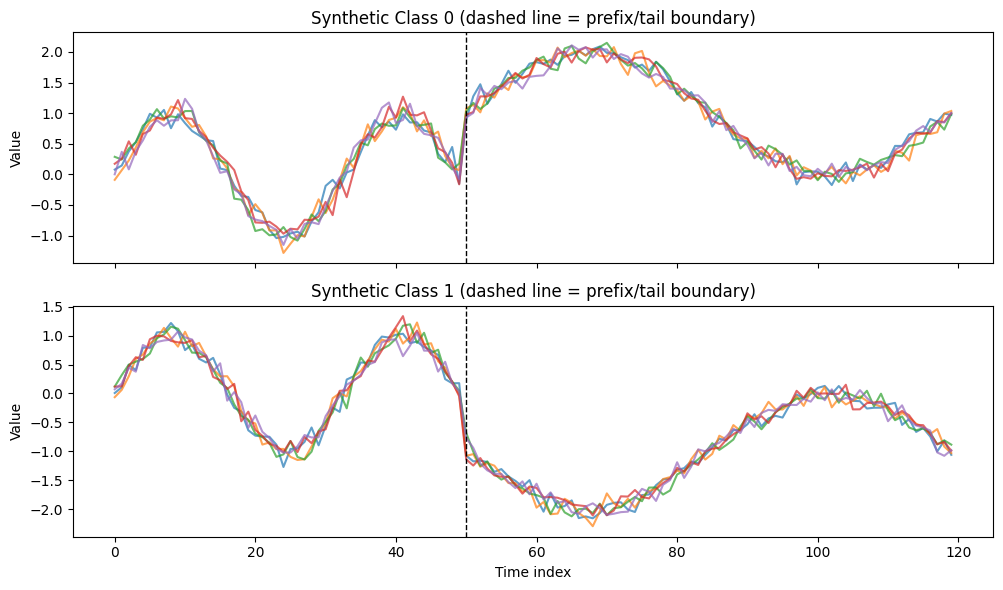

In [ ]:
# Visualize a few synthetic samples
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for cls, ax in zip([0, 1], axes):
    idx = np.where(y_train == cls)[0][:5]
    for i in idx:
        ax.plot(X_train[i], alpha=0.7)
    ax.axvline(PIVOT, linestyle='--', color='black', linewidth=1)
    ax.set_title(f'Synthetic Class {cls} (dashed line = prefix/tail boundary)')
    ax.set_ylabel('Value')
axes[-1].set_xlabel('Time index')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'task_3_2_synthetic_samples.png', dpi=200)
plt.show()

**Cell 2 - What this code does:**
Visualizes class-wise synthetic samples and marks the prefix-tail boundary, then saves `results/task_3_2_synthetic_samples.png`.


In [ ]:
prefix_ratios = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []

for ratio in prefix_ratios:
    length = max(1, int(SERIES_LEN * ratio))
    clf = KNeighborsClassifier(n_neighbors=1, metric='euclidean', n_jobs=-1)
    clf.fit(X_train[:, :length], y_train)
    pred = clf.predict(X_test[:, :length])
    acc = accuracy_score(y_test, pred)
    rows.append({'prefix_ratio': ratio, 'prefix_percent': int(ratio * 100), 'prefix_length': length, 'accuracy': acc})

failure_df = pd.DataFrame(rows)
failure_df

,prefix_ratio,prefix_percent,prefix_length,accuracy
0,0.2,20,24,0.515
1,0.4,40,48,0.460
2,0.6,60,72,1.000
3,0.8,80,96,1.000
4,1.0,100,120,1.000


**Cell 3 - What this code does:**
Evaluates 1NN accuracy at increasing prefix ratios and builds the failure table.

**Expected pattern:**
Low accuracy at short prefixes, sharp recovery once informative tail points are included.


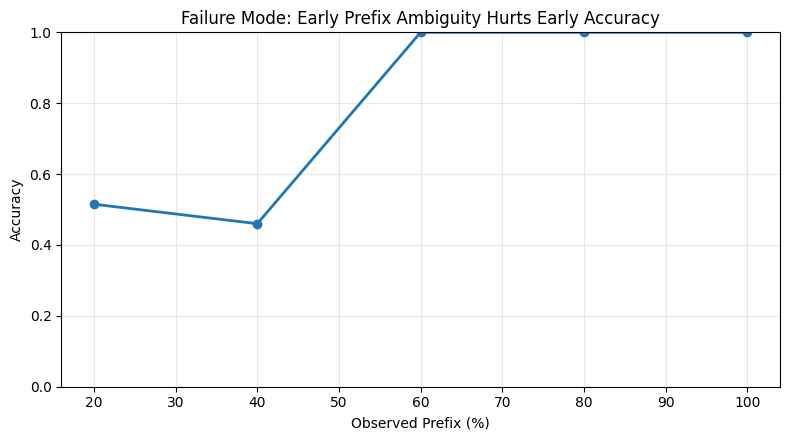

 prefix_ratio  prefix_percent  prefix_length  accuracy
          0.2              20             24     0.515
          0.4              40             48     0.460
          0.6              60             72     1.000
          0.8              80             96     1.000
          1.0             100            120     1.000


In [ ]:
plt.figure(figsize=(8, 4.5))
plt.plot(failure_df['prefix_percent'], failure_df['accuracy'], marker='o', linewidth=2)
plt.xlabel('Observed Prefix (%)')
plt.ylabel('Accuracy')
plt.title('Failure Mode: Early Prefix Ambiguity Hurts Early Accuracy')
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'task_3_2_failure_curve.png', dpi=200)
plt.show()

failure_df.to_csv(RESULTS_DIR / 'task_3_2_failure_accuracy.csv', index=False)
print(failure_df.to_string(index=False))

**Cell 4 - What this code does:**
Plots and saves the failure curve (`results/task_3_2_failure_curve.png`) and stores the numeric table (`results/task_3_2_failure_accuracy.csv`).


## Failure Mode Interpretation

Short-prefix performance is poor (about 0.515 at 20% and 0.460 at 40%), close to chance for binary classification. After the prefix crosses the synthetic pivot, accuracy jumps to 1.00, showing that informative evidence exists but appears late. This confirms a structural early-prediction failure: nearest-neighbor decisions cannot be reliable when early observations are deliberately non-discriminative. The violated assumption is exactly the one identified in Task 1.2 about informative prefixes. So the issue is not just parameter tuning; it is data regime mismatch with method assumptions. A practical mitigation is a confidence-based defer rule: when early class margin is small, delay prediction until more timesteps are observed.
